# 🧬 Cuaderno 03 BLAST y Búsqueda por Similitud

**Curso:** Bioinformática
**Repositorio:** `bio-notebooks`  
**Herramientas:** Python 3, Biopython, matplotlib, pandas

## Competencias
- Comprender el funcionamiento del algoritmo BLAST
- Ejecutar búsquedas BLAST remotas desde Python con Biopython
- Interpretar los resultados: E-value, score, identidad, cobertura
- Comparar BLAST con Smith-Waterman

## Contenido
1. Marco teórico ¿qué es BLAST y por qué es más rápido que SW?
2. Conceptos clave: E-value, score, identidad, cobertura
3. BLAST remoto con Biopython (NCBI)
4. Lectura de secuencia query desde archivo FASTA
5. Análisis e interpretación de resultados
6. Visualización de hits
7. Comparativa BLAST vs Smith-Waterman
8. Preguntas de reflexión


## 1. Marco Teórico

### 1.1 ¿Qué es BLAST?

**BLAST** (Basic Local Alignment Search Tool) es el algoritmo más utilizado
en bioinformática para buscar secuencias similares en bases de datos.
Fue publicado por Altschul et al. en 1990 y es una **heurística** basada en
Smith-Waterman — sacrifica exactitud para ganar velocidad.

### 1.2 ¿Por qué BLAST y no Smith-Waterman directo?

| Aspecto | Smith-Waterman | BLAST |
|---|---|---|
| Exactitud | Óptimo garantizado | Heurístico (casi óptimo) |
| Complejidad | O(n × m) | O(n × k) aprox. |
| Velocidad | Lento para BD grandes | Miles de veces más rápido |
| Uso | Secuencias cortas | Búsqueda en genomas/BD |

### 1.3 ¿Cómo funciona BLAST? (3 fases)

**Fase 1  Semillas (seeds)**
Divide la query en k-mers (palabras de longitud k, típicamente k=11 para ADN).
Solo extiende desde posiciones donde hay una coincidencia exacta o casi exacta.

**Fase 2  Extensión**
Extiende cada semilla en ambas direcciones mientras el score no caiga por debajo
de un umbral (drop-off). Genera **High-scoring Segment Pairs (HSPs)**.

**Fase 3  Evaluación estadística**
Calcula el **E-value** de cada HSP para determinar si es significativo.

### 1.4 Métricas clave

| Métrica | Descripción | Bueno cuando |
|---|---|---|
| **E-value** | Hits esperados por azar en una BD del mismo tamaño | < 0.001 |
| **Score** | Puntuación del alineamiento (bits) | Mayor = mejor |
| **Identidad %** | Bases iguales / longitud alineada × 100 | > 90% para misma especie |
| **Cobertura %** | Longitud alineada / longitud query × 100 | > 80% relevante |

### 1.5 Bases de datos principales

| Base de datos | Contenido | Cuándo usarla |
|---|---|---|
| `nt` | Nucleótidos (todas las especies) | Búsqueda general de ADN |
| `nr` | Proteínas no redundantes | Búsqueda de proteínas |
| `refseq_rna` | mRNA de referencia | Genes bien anotados |
| `refseq_genomic` | Genomas de referencia | Alineamiento genómico |


## 2. Importaciones

In [1]:
import time
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from Bio import Entrez, SeqIO
from Bio.Blast import NCBIWWW, NCBIXML

# Email requerido por NCBI
Entrez.email = "tu_email@example.com"

print("Librerías cargadas correctamente.")
print("Recuerda reemplazar 'tu_email@example.com' con tu email real.")


Librerías cargadas correctamente.
Recuerda reemplazar 'tu_email@example.com' con tu email real.


## 3. Secuencia Query

Usamos los primeros **200 nt** de BRCA1 humano como query.
El archivo debe estar en `data/U14680.1.fasta`.

> Para descargarla: https://www.ncbi.nlm.nih.gov/nuccore/U14680.1?report=fasta


In [2]:
def leer_fasta(filepath: str) -> tuple[str, str, str]:
    """Lee un FASTA y retorna (id, descripcion, secuencia)."""
    with open(filepath, 'r') as f:
        lines = f.readlines()
    header = lines[0].strip()[1:]
    seq_id = header.split()[0]
    desc   = ' '.join(header.split()[1:])
    seq    = ''.join(l.strip() for l in lines[1:]).upper()
    return seq_id, desc, seq


DATA_DIR = "data"
query_id, query_desc, query_full = leer_fasta(
    os.path.join(DATA_DIR, "U14680.1.fasta")
)

# Usar primeros 200 nt para que la búsqueda sea rápida
query_seq = query_full[:200]

print(f"Query ID   : {query_id}")
print(f"Descripción: {query_desc[:60]}...")
print(f"Longitud   : {len(query_full):,} bp (usando primeros {len(query_seq)} nt)")
print(f"Secuencia  : {query_seq[:60]}...")


Query ID   : U14680.1
Descripción: Homo sapiens breast and ovarian cancer susceptibility (BRCA1...
Longitud   : 5,711 bp (usando primeros 200 nt)
Secuencia  : AGCTCGCTGAGACTTCCTGGACCCCGCACCAGGCTGTGGGGTTTCTCAGATAACTGGGCC...


## 4. BLAST Remoto con Biopython

Ejecutamos `blastn` contra la base de datos `nt` de NCBI.
La búsqueda tarda entre 30 segundos y varios minutos dependiendo del tráfico de NCBI.

> El resultado se guarda en `data/blast_result.xml` para no repetir la búsqueda.


In [3]:
BLAST_RESULT_FILE = os.path.join(DATA_DIR, "blast_result.xml")

if os.path.exists(BLAST_RESULT_FILE):
    print(f"Resultado encontrado en caché: {BLAST_RESULT_FILE}")
    print("Cargando resultado guardado...")
else:
    print(f"Ejecutando BLAST remoto para: {query_id} ({len(query_seq)} nt)")
    print("Esto puede tardar 1-3 minutos...")
    t0 = time.perf_counter()

    result_handle = NCBIWWW.qblast(
        program   = "blastn",
        database  = "nt",
        sequence  = query_seq,
        hitlist_size = 20,
        expect    = 0.001,
    )

    with open(BLAST_RESULT_FILE, 'w') as f:
        f.write(result_handle.read())
    result_handle.close()

    elapsed = time.perf_counter() - t0
    print(f"BLAST completado en {elapsed:.1f}s")
    print(f"Resultado guardado en: {BLAST_RESULT_FILE}")

print("Listo.")


Ejecutando BLAST remoto para: U14680.1 (200 nt)
Esto puede tardar 1-3 minutos...
BLAST completado en 83.7s
Resultado guardado en: data\blast_result.xml
Listo.


## 5. Parsear e Interpretar Resultados

Extraemos los campos más importantes de cada hit:
- **Accession** — identificador del hit en la base de datos
- **Descripción** — nombre del gen/organismo
- **Score** — puntuación del alineamiento en bits
- **E-value** — probabilidad de que el hit sea por azar
- **Identidad %** — porcentaje de bases iguales
- **Cobertura %** — qué fracción de la query está cubierta


In [4]:
with open(BLAST_RESULT_FILE) as f:
    blast_record = NCBIXML.read(f)

rows = []
for alignment in blast_record.alignments:
    for hsp in alignment.hsps:
        identidad  = hsp.identities / hsp.align_length * 100
        cobertura  = hsp.align_length / len(query_seq) * 100
        rows.append({
            "Accession"   : alignment.accession,
            "Descripcion" : alignment.title[:55] + "...",
            "Score"       : hsp.score,
            "E-value"     : hsp.expect,
            "Identidad %"  : round(identidad, 1),
            "Cobertura %"  : round(cobertura, 1),
            "Long. aln"   : hsp.align_length,
        })

df = pd.DataFrame(rows)
print(f"Hits encontrados: {len(df)}")
print()
print(df[["Accession","Score","E-value","Identidad %","Cobertura %"]].to_string(index=False))


Hits encontrados: 20

   Accession  Score      E-value  Identidad %  Cobertura %
      U14680  400.0 1.760630e-95        100.0        100.0
    BC030969  371.0 2.447310e-87         97.5        100.0
    BC115037  371.0 2.447310e-87         97.5        100.0
    BC012577  371.0 2.447310e-87         97.5        100.0
XM_055388028  366.0 2.981440e-86         97.0        100.0
XM_055388026  366.0 2.981440e-86         97.0        100.0
XM_055388048  366.0 2.981440e-86         97.0        100.0
XM_055388044  366.0 2.981440e-86         97.0        100.0
XM_055388042  366.0 2.981440e-86         97.0        100.0
XM_055388022  366.0 2.981440e-86         97.0        100.0
XM_055388031  366.0 2.981440e-86         97.0        100.0
XM_055388037  366.0 2.981440e-86         97.0        100.0
XM_055388035  366.0 2.981440e-86         97.0        100.0
XM_031011560  366.0 2.981440e-86         97.0        100.0
XM_055388052  366.0 2.981440e-86         97.0        100.0
XM_055388050  366.0 2.981440e-86  

## 6. Top 5 Hits — Análisis Detallado

In [5]:
print("Top 5 hits por E-value:")
print()
top5 = df.nsmallest(5, "E-value")

for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"  Hit #{i}")
    print(f"    Accession  : {row['Accession']}")
    print(f"    Score      : {row['Score']:.0f} bits")
    print(f"    E-value    : {row['E-value']:.2e}")
    print(f"    Identidad  : {row['Identidad %']:.1f}%")
    print(f"    Cobertura  : {row['Cobertura %']:.1f}%")
    print()


Top 5 hits por E-value:

  Hit #1
    Accession  : U14680
    Score      : 400 bits
    E-value    : 1.76e-95
    Identidad  : 100.0%
    Cobertura  : 100.0%

  Hit #2
    Accession  : BC030969
    Score      : 371 bits
    E-value    : 2.45e-87
    Identidad  : 97.5%
    Cobertura  : 100.0%

  Hit #3
    Accession  : BC115037
    Score      : 371 bits
    E-value    : 2.45e-87
    Identidad  : 97.5%
    Cobertura  : 100.0%

  Hit #4
    Accession  : BC012577
    Score      : 371 bits
    E-value    : 2.45e-87
    Identidad  : 97.5%
    Cobertura  : 100.0%

  Hit #5
    Accession  : XM_055388028
    Score      : 366 bits
    E-value    : 2.98e-86
    Identidad  : 97.0%
    Cobertura  : 100.0%



## 7. Visualización de Hits

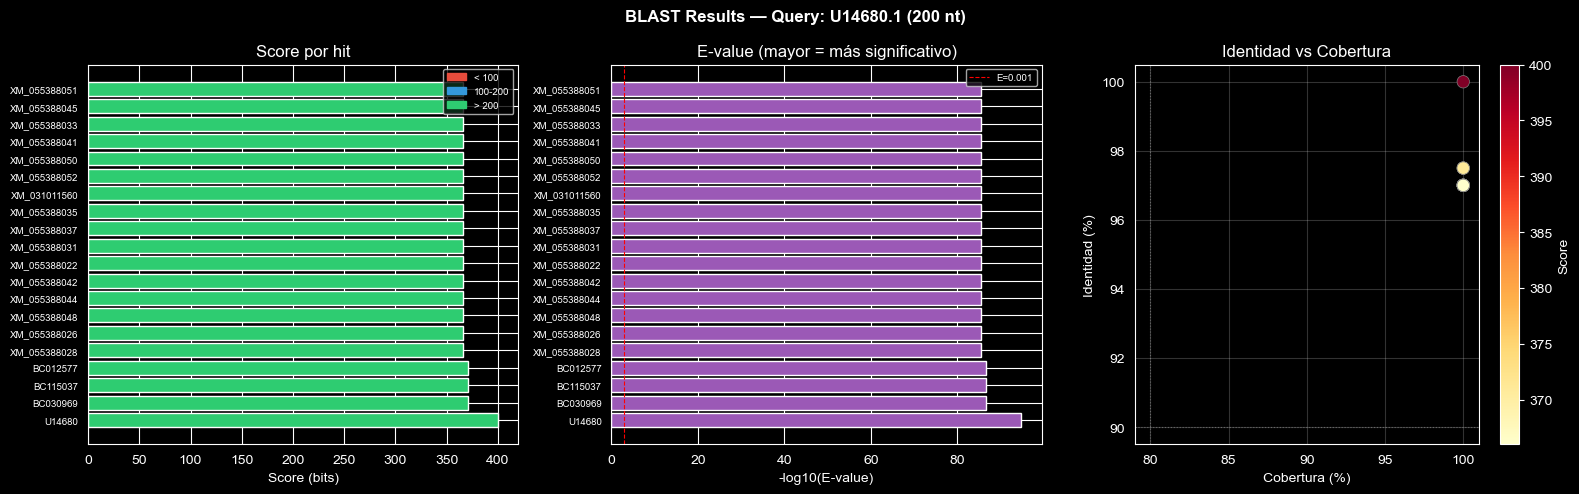

In [6]:
if len(df) == 0:
    print("Sin resultados para visualizar.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f"BLAST Results — Query: {query_id} ({len(query_seq)} nt)",
                 fontsize=12, fontweight='bold')

    accessions = [a[:12] for a in df["Accession"].tolist()]

    # Panel 1: Score por hit
    ax1 = axes[0]
    colors_score = ['#e74c3c' if s < 100 else '#3498db' if s < 200 else '#2ecc71'
                    for s in df["Score"]]
    ax1.barh(range(len(df)), df["Score"], color=colors_score, edgecolor='white')
    ax1.set_yticks(range(len(df)))
    ax1.set_yticklabels(accessions, fontsize=7)
    ax1.set_xlabel("Score (bits)")
    ax1.set_title("Score por hit")
    patches = [mpatches.Patch(color='#e74c3c', label='< 100'),
               mpatches.Patch(color='#3498db', label='100-200'),
               mpatches.Patch(color='#2ecc71', label='> 200')]
    ax1.legend(handles=patches, fontsize=7)

    # Panel 2: E-value (escala log)
    ax2 = axes[1]
    evalues = df["E-value"].replace(0, 1e-180)
    ax2.barh(range(len(df)), -evalues.apply(lambda x: __import__('math').log10(x)),
             color='#9b59b6', edgecolor='white')
    ax2.set_yticks(range(len(df)))
    ax2.set_yticklabels(accessions, fontsize=7)
    ax2.set_xlabel("-log10(E-value)")
    ax2.set_title("E-value (mayor = más significativo)")
    ax2.axvline(3, color='red', linestyle='--', linewidth=0.8, label='E=0.001')
    ax2.legend(fontsize=7)

    # Panel 3: Identidad vs Cobertura
    ax3 = axes[2]
    sc = ax3.scatter(df["Cobertura %"], df["Identidad %"],
                     c=df["Score"], cmap='YlOrRd', s=80,
                     edgecolors='gray', linewidth=0.5, zorder=3)
    plt.colorbar(sc, ax=ax3, label='Score')
    ax3.set_xlabel("Cobertura (%)")
    ax3.set_ylabel("Identidad (%)")
    ax3.set_title("Identidad vs Cobertura")
    ax3.axvline(80, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
    ax3.axhline(90, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
    ax3.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()


## 8. Comparativa BLAST vs Smith-Waterman

Corremos SW sobre los mismos hits del top 5 para comparar scores.


In [7]:
import numpy as np
from dataclasses import dataclass

@dataclass
class ScoreParams:
    match: int = 2; mismatch: int = -1; gap: int = -2
    def score(self, a, b): return self.match if a.upper()==b.upper() else self.mismatch

@dataclass
class AlignmentResult:
    seq1_aligned: str; seq2_aligned: str
    score: int; matrix: np.ndarray; algorithm: str

    @property
    def identity(self):
        m = sum(a==b for a,b in zip(self.seq1_aligned,self.seq2_aligned) if a!='-' and b!='-')
        l = max(len(self.seq1_aligned), len(self.seq2_aligned))
        return m/l*100 if l else 0.0

class SmithWaterman:
    def __init__(self, p=ScoreParams()): self.p = p
    def align(self, s1, s2):
        n,m = len(s1),len(s2)
        H = np.zeros((n+1,m+1),dtype=int)
        for i in range(1,n+1):
            for j in range(1,m+1):
                H[i][j] = max(0,
                    H[i-1][j-1]+self.p.score(s1[i-1],s2[j-1]),
                    H[i-1][j]+self.p.gap, H[i][j-1]+self.p.gap)
        i,j = map(int,np.unravel_index(np.argmax(H),H.shape))
        sc = int(H[i][j]); a1=a2=''
        while i>0 and j>0 and H[i][j]>0:
            if H[i][j]==H[i-1][j-1]+self.p.score(s1[i-1],s2[j-1]):
                a1=s1[i-1]+a1; a2=s2[j-1]+a2; i-=1; j-=1
            elif H[i][j]==H[i-1][j]+self.p.gap:
                a1=s1[i-1]+a1; a2='-'+a2; i-=1
            else:
                a1='-'+a1; a2=s2[j-1]+a2; j-=1
        return AlignmentResult(a1,a2,sc,H,"Smith-Waterman")


params = ScoreParams()
sw     = SmithWaterman(params)

print("Comparación BLAST vs Smith-Waterman")
print()
print(f"  {'Accession':<14} {'BLAST Score':>12} {'SW Score':>10} {'BLAST Id%':>10} {'SW Id%':>8}")
print(f"  {'':-<14}  {'':-<12}  {'':-<10}  {'':-<10}  {'':-<8}")

for _, row in top5.iterrows():
    try:
        handle = Entrez.efetch(db="nucleotide", id=row['Accession'],
                               rettype="fasta", retmode="text")
        rec    = SeqIO.read(handle, "fasta")
        handle.close()
        hit_seq = str(rec.seq).upper()[:200]
        time.sleep(0.4)
        res_sw  = sw.align(query_seq[:50], hit_seq[:50])
        print(f"  {row['Accession']:<14} {row['Score']:>12.0f} {res_sw.score:>10} "
              f"{row['Identidad %']:>9.1f}% {res_sw.identity:>7.1f}%")
    except Exception:
        print(f"  {row['Accession']:<14} {row['Score']:>12.0f} {'N/A':>10} "
              f"{row['Identidad %']:>9.1f}% {'N/A':>8}")


Comparación BLAST vs Smith-Waterman

  Accession       BLAST Score   SW Score  BLAST Id%   SW Id%
  --------------  ------------  ----------  ----------  --------
  U14680                  400        100     100.0%   100.0%
  BC030969                371         84      97.5%    90.0%
  BC115037                371         48      97.5%    84.4%
  BC012577                371         76      97.5%    89.1%
  XM_055388028            366         21      97.0%    60.6%


## 9. Preguntas de Reflexión

1. **¿Qué significa un E-value de 1e-50? ¿Y uno de 0.5?
   ¿Cuál considerarías significativo y por qué?**  
   _Responde aquí..._

2. **Un hit tiene identidad 99% pero cobertura 10%.
   ¿Es un buen hit? ¿Qué podría indicar biológicamente?**  
   _Responde aquí..._

3. **¿Por qué BLAST divide la query en k-mers antes de buscar?
   ¿Qué ventaja tiene sobre comparar toda la query directamente?**  
   _Responde aquí..._

4. **Si buscas una secuencia de ADN humano en la base de datos `nt`,
   ¿esperarías encontrar hits en otros mamíferos? ¿Por qué?**  
   _Responde aquí..._

5. **¿En qué situación usarías `blastp` en lugar de `blastn`?**  
   _Responde aquí..._

## 10. Conclusiones

- **BLAST** es una heurística basada en Smith-Waterman que escala a bases
  de datos de miles de millones de nucleótidos
- El **E-value** es la métrica más importante: indica significancia estadística,
  no solo similitud
- **Identidad y cobertura juntas** determinan si un hit es biológicamente relevante
- Biopython permite automatizar búsquedas BLAST y procesar resultados en Python
- Los resultados se guardan en XML para no repetir búsquedas costosas

## 11. Referencias

- Altschul, S.F. et al. (1990). *Basic local alignment search tool.*
  Journal of Molecular Biology, 215(3), 403-410.
- NCBI BLAST: https://blast.ncbi.nlm.nih.gov/
- Biopython BLAST tutorial: https://biopython.org/DIST/docs/tutorial/Tutorial.html
